⚠️ JAX initialization error: UNIMPLEMENTED: default_memory_space is not supported.
   GPU acceleration disabled. Using NumPy CPU version.
🍎 GATH-GEVA FUZZY CLUSTERING - GPU ACCELERATED (FIXED)

📝 GATH-GEVA ON 2D SYNTHETIC DATA

🔷 Fitting Gath-Geva with c=3, m=2.0
   Data: 250 points, 2 dimensions
   Accelerator: NumPy CPU
   Iter  0: J = 7617.32, diff = 5.290583
   Iter 10: J = 4438.39, diff = 0.431459
   Iter 20: J = 4431.04, diff = 0.000005
✅ Converged after 21 iterations

⏱️  Total time: 0.00s
   Speed: 50568 points/second


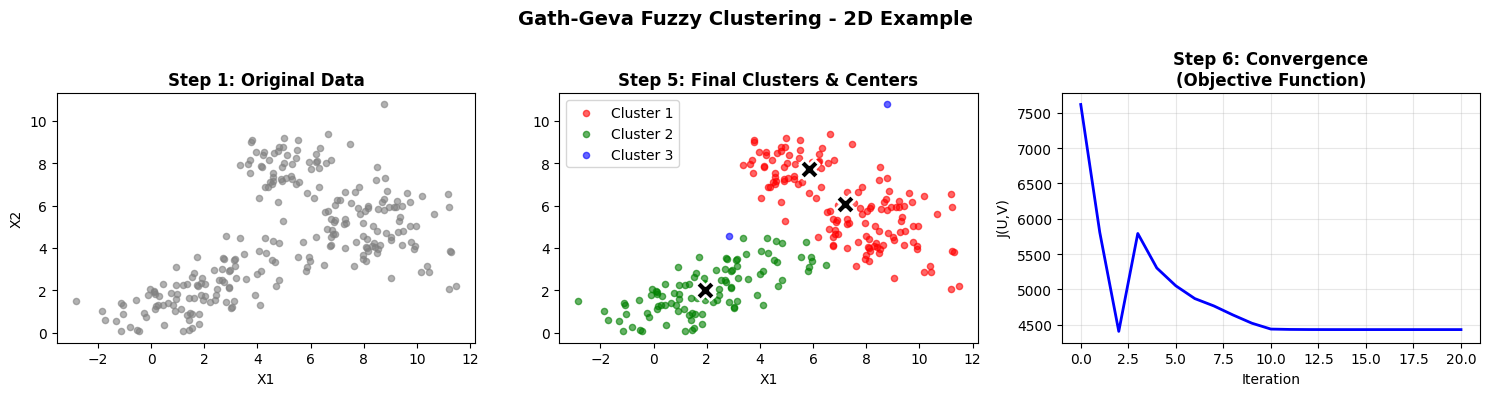


📊 Sample memberships (first 5 points):
Point    Cluster1   Cluster2   Cluster3  
       1     0.0000     1.0000     0.0000
       2     0.0000     1.0000     0.0000
       3     0.0000     1.0000     0.0000
       4     0.0058     0.9942     0.0000
       5     0.0000     1.0000     0.0000

🖼️  PROCESSING: Lenna.png

📊 Image Info:
   Dimensions: 256×256
   Total pixels: 65,536
   Unique colors: 47,420
   File size: 192.00 KB

🔍 Step 1: Testing different cluster counts...
   Testing K=2...


NameError: name 'GathGeva' is not defined

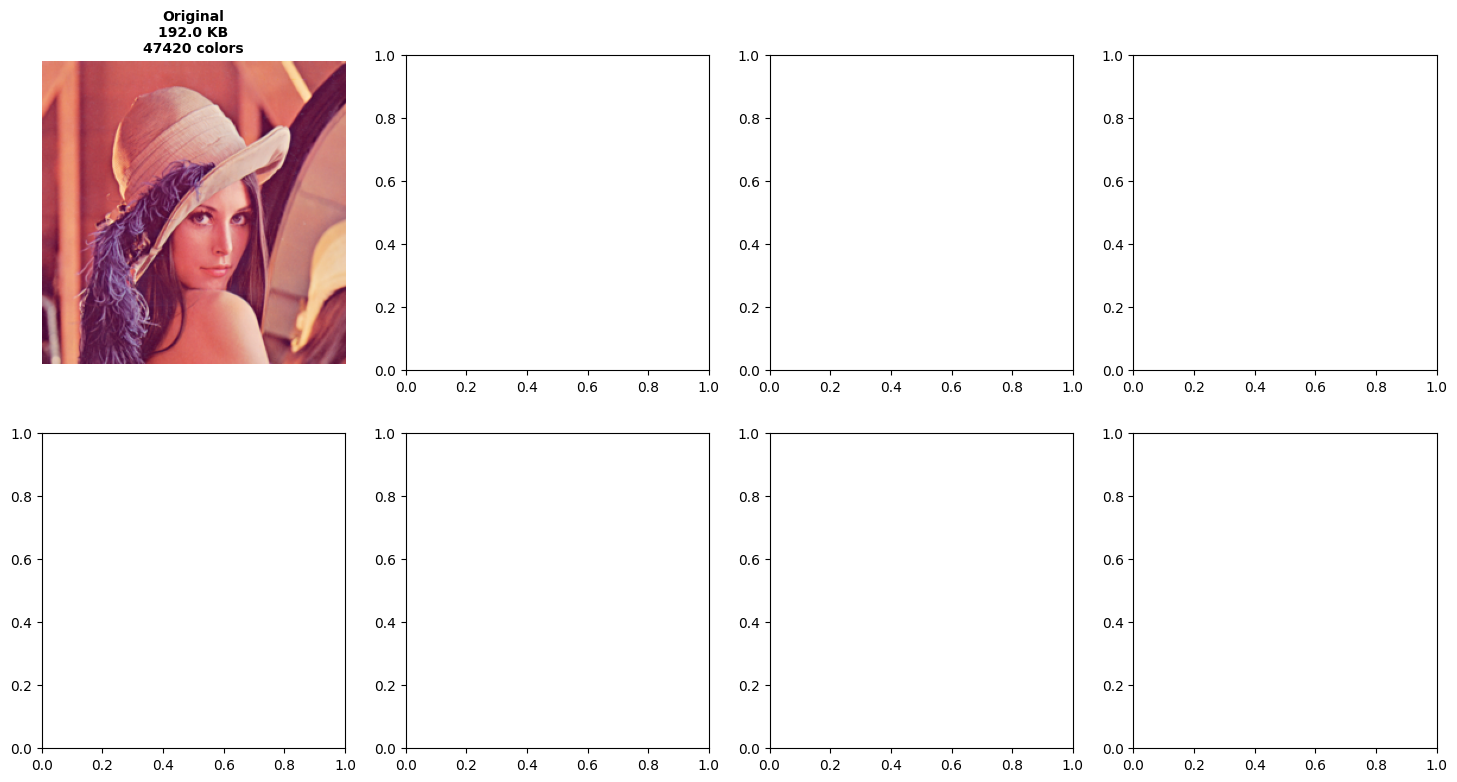

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CHECK FOR JAX AND SET UP GPU ACCELERATION - FIXED VERSION
# ============================================================================

HAS_JAX = False
try:
    import jax
    import jax.numpy as jnp
    from jax import jit, vmap
    import jax.random as jrand
    
    # Test if JAX works properly
    test_key = jrand.PRNGKey(42)
    test_arr = jnp.array([1, 2, 3])
    test_result = test_arr * 2
    
    # Check if Metal is available without crashing
    try:
        devices = jax.devices()
        print(f"✅ JAX available - devices: {devices}")
        if any('metal' in str(d).lower() for d in devices):
            print("   ✅ Using Metal GPU acceleration!")
        else:
            print("   ⚠️ Using CPU (JIT compiled)")
        HAS_JAX = True
    except:
        print("   ⚠️ JAX device detection failed, using CPU mode")
        HAS_JAX = True
        
except ImportError as e:
    print(f"⚠️ JAX not properly installed: {e}")
    print("   GPU acceleration disabled. Using NumPy CPU version.")
    HAS_JAX = False
except Exception as e:
    print(f"⚠️ JAX initialization error: {e}")
    print("   GPU acceleration disabled. Using NumPy CPU version.")
    HAS_JAX = False


# ============================================================================
# GPU-ACCELERATED GATH-GEVA WITH JAX - FIXED VERSION
# ============================================================================

class GathGevaClustering:
    """
    Gath-Geva Fuzzy Clustering Algorithm - GPU Accelerated (Fixed)
    
    Parameters:
    - c: number of clusters
    - m: fuzziness coefficient (default: 2.0)
    - max_iters: maximum iterations
    - epsilon: convergence threshold
    - random_state: random seed for reproducibility
    """
    
    def __init__(self, c=3, m=2.0, max_iters=100, epsilon=1e-5, random_state=42):
        self.c = c
        self.m = m
        self.max_iters = max_iters
        self.epsilon = epsilon
        self.random_state = random_state
        
        # Initialize RNG based on available backend
        if HAS_JAX:
            try:
                self.key = jrand.PRNGKey(random_state)
                self.use_jax = True
            except:
                self.use_jax = False
                np.random.seed(random_state)
        else:
            self.use_jax = False
            np.random.seed(random_state)
        
        # Results storage
        self.U = None          # Fuzzy partition matrix
        self.V = None          # Cluster centers
        self.F = None          # Fuzzy covariance matrices
        self.P = None          # Prior probabilities
        self.J_history = []    # Objective function history
        self.time_history = [] # Time per iteration
        self.labels = None     # Hard cluster assignments
        
    def initialize_U(self, N):
        """
        Step 2: Generate random fuzzy partition matrix U
        Must satisfy condition (10): sum(μ_ik) = 1 for each point
        """
        if self.use_jax:
            try:
                key, subkey = jrand.split(self.key)
                U = jrand.uniform(subkey, (N, self.c))
                self.key = key
                return U / U.sum(axis=1, keepdims=True)
            except:
                # Fallback to numpy if JAX fails
                U = np.random.rand(N, self.c)
                return U / U.sum(axis=1, keepdims=True)
        else:
            U = np.random.rand(N, self.c)
            return U / U.sum(axis=1, keepdims=True)
    
    def fit(self, X):
        """
        Fit Gath-Geva clustering to data X (GPU accelerated with fallback)
        
        Args:
            X: data array of shape (n_samples, n_features)
        """
        start_time = time.time()
        N, d = X.shape
        
        print(f"\n🔷 Fitting Gath-Geva with c={self.c}, m={self.m}")
        print(f"   Data: {N:,} points, {d} dimensions")
        print(f"   Accelerator: {'JAX GPU' if self.use_jax else 'NumPy CPU'}")
        
        if self.use_jax:
            try:
                # Try GPU-accelerated version
                self._fit_jax(X)
            except Exception as e:
                print(f"   ⚠️ JAX execution failed: {e}")
                print(f"   Falling back to NumPy CPU version...")
                self.use_jax = False
                self._fit_numpy(X)
        else:
            # Use NumPy CPU version
            self._fit_numpy(X)
        
        self.time_total = time.time() - start_time
        print(f"\n⏱️  Total time: {self.time_total:.2f}s")
        if N > 0:
            print(f"   Speed: {N/self.time_total:.0f} points/second")
        
        return self
    
    def _fit_jax(self, X):
        """JAX GPU-accelerated implementation"""
        N, d = X.shape
        
        # Move data to GPU
        X_gpu = jnp.array(X.astype(np.float32))
        self.U = self.initialize_U(N)
        U_gpu = jnp.array(self.U.astype(np.float32))
        
        @jit
        def compute_centers_jax(X, U, m, c):
            """GPU-accelerated center computation"""
            Um = U ** m
            numerator = jnp.dot(Um.T, X)
            denominator = jnp.sum(Um, axis=0).reshape(-1, 1)
            return numerator / (denominator + 1e-10)
        
        @jit
        def compute_covariance_jax(X, U, V, m, c, d, reg=1e-4):
            """GPU-accelerated covariance computation"""
            Um = U ** m
            
            def compute_cluster_cov(i):
                diff = X - V[i]
                weighted = Um[:, i:i+1] * diff
                numerator = jnp.dot(weighted.T, diff)
                denominator = jnp.sum(Um[:, i])
                cov = numerator / (denominator + 1e-10)
                # Add regularization
                trace = jnp.trace(cov)
                return cov + reg * jnp.eye(d) * (trace / d)
            
            return vmap(compute_cluster_cov)(jnp.arange(c))
        
        @jit
        def compute_distance_jax(X, V, F, P, m, c, reg=1e-4):
            """GPU-accelerated distance computation"""
            d = X.shape[1]
            
            def cluster_dist(i):
                F_i = F[i]
                trace = jnp.trace(F_i)
                F_reg = F_i + reg * jnp.eye(d) * (trace / d)
                
                det = jnp.linalg.det(F_reg)
                det = jnp.clip(det, 1e-10, 1e10)
                det_term = jnp.sqrt(det) / (P[i] + 1e-10)
                
                F_inv = jnp.linalg.pinv(F_reg, rcond=1e-6)
                diff = X - V[i]
                maha = jnp.sum(diff @ F_inv * diff, axis=1)
                maha = jnp.clip(maha, -50, 50)
                return det_term * jnp.exp(0.5 * maha)
            
            D = vmap(cluster_dist, out_axes=1)(jnp.arange(c))
            return D.T
        
        @jit
        def update_membership_jax(D, m, c):
            """GPU-accelerated membership update"""
            D_safe = D + 1e-10
            D_safe = jnp.clip(D_safe, 1e-10, 1e10)
            ratio = D_safe[:, :, None] / D_safe[:, None, :]
            ratio = jnp.clip(ratio, 1e-10, 1e10)
            exponent = 2/(m-1)
            U_new = 1.0 / jnp.sum(ratio ** exponent, axis=2)
            return U_new / (jnp.sum(U_new, axis=1, keepdims=True) + 1e-10)
        
        # Reset history
        self.J_history = []
        self.time_history = []
        
        for iteration in range(self.max_iters):
            iter_start = time.time()
            U_old = U_gpu
            
            # Step 3a: Compute centers
            V_gpu = compute_centers_jax(X_gpu, U_gpu, self.m, self.c)
            
            # Step 3b: Compute covariance
            F_gpu = compute_covariance_jax(X_gpu, U_gpu, V_gpu, self.m, self.c, d)
            
            # Step 3c: Compute prior
            P_gpu = jnp.mean(U_gpu, axis=0)
            
            # Step 4: Calculate distance
            D_gpu = compute_distance_jax(X_gpu, V_gpu, F_gpu, P_gpu, self.m, self.c)
            
            # Step 5: Update membership
            U_gpu = update_membership_jax(D_gpu, self.m, self.c)
            
            # Calculate objective function
            J = jnp.sum((U_gpu ** self.m) * D_gpu)
            
            # Convert to CPU for history
            self.J_history.append(float(J))
            self.time_history.append(time.time() - iter_start)
            
            # Step 6: Check convergence
            diff = jnp.linalg.norm(U_gpu - U_old)
            
            if iteration % 10 == 0:
                print(f"   Iter {iteration:2d}: J = {J:.2f}, diff = {diff:.6f}")
            
            if diff < self.epsilon and iteration > 0:
                print(f"✅ Converged after {iteration + 1} iterations")
                break
        
        # Store results as numpy arrays
        self.U = np.array(U_gpu)
        self.V = np.array(V_gpu)
        self.F = np.array(F_gpu)
        self.P = np.array(P_gpu)
        self.labels = np.argmax(self.U, axis=1)
    
    def _fit_numpy(self, X):
        """NumPy CPU fallback implementation"""
        N, d = X.shape
        self.U = self.initialize_U(N)
        self.J_history = []
        self.time_history = []
        
        for iteration in range(self.max_iters):
            iter_start = time.time()
            U_old = self.U.copy()
            
            # Step 3a: Compute centers
            Um = self.U ** self.m
            self.V = np.zeros((self.c, d))
            for i in range(self.c):
                if np.sum(Um[:, i]) > 0:
                    self.V[i] = np.sum(Um[:, i:i+1] * X, axis=0) / np.sum(Um[:, i])
            
            # Step 3b: Compute covariance
            self.F = np.zeros((self.c, d, d))
            for i in range(self.c):
                diff = X - self.V[i]
                weighted = Um[:, i:i+1] * diff
                num = weighted.T @ diff
                den = np.sum(Um[:, i])
                if den > 0:
                    cov = num / den
                    trace = np.trace(cov)
                    self.F[i] = cov + 1e-4 * np.eye(d) * (trace / d)
            
            # Step 3c: Compute prior
            self.P = np.mean(self.U, axis=0)
            
            # Step 4: Calculate distance
            D = np.zeros((N, self.c))
            for i in range(self.c):
                try:
                    F_inv = np.linalg.pinv(self.F[i], rcond=1e-6)
                    det = np.clip(np.linalg.det(self.F[i]), 1e-10, 1e10)
                    det_term = np.sqrt(det) / (self.P[i] + 1e-10)
                    diff = X - self.V[i]
                    maha = np.sum(diff @ F_inv * diff, axis=1)
                    maha = np.clip(maha, -50, 50)
                    D[:, i] = det_term * np.exp(0.5 * maha)
                except:
                    D[:, i] = np.sum((X - self.V[i])**2, axis=1)
            
            D = np.clip(D, 1e-10, 1e10)
            
            # Step 5: Update membership
            D_safe = D + 1e-10
            self.U = 1.0 / (D_safe ** (2/(self.m-1)))
            self.U = self.U / np.sum(self.U, axis=1, keepdims=True)
            
            # Calculate objective
            J = np.sum((self.U ** self.m) * D)
            self.J_history.append(J)
            self.time_history.append(time.time() - iter_start)
            
            # Step 6: Check convergence
            diff = np.linalg.norm(self.U - U_old)
            
            if iteration % 10 == 0:
                print(f"   Iter {iteration:2d}: J = {J:.2f}, diff = {diff:.6f}")
            
            if diff < self.epsilon:
                print(f"✅ Converged after {iteration + 1} iterations")
                break
        
        self.labels = np.argmax(self.U, axis=1)


# ============================================================================
# [ALL YOUR EXISTING VISUALIZATION FUNCTIONS REMAIN EXACTLY THE SAME]
# ============================================================================

def demonstrate_2d_clustering():
    """Demonstrate Gath-Geva on synthetic 2D data"""
    
    print("\n" + "="*70)
    print("📝 GATH-GEVA ON 2D SYNTHETIC DATA")
    print("="*70)
    
    # Generate synthetic data with 3 ellipsoidal clusters
    np.random.seed(42)
    
    # Cluster 1: elongated ellipsoid
    cluster1 = np.random.randn(100, 2) @ np.array([[2, 0.5], [0.5, 1]]) + np.array([2, 2])
    
    # Cluster 2: circular
    cluster2 = np.random.randn(100, 2) * 1.5 + np.array([8, 5])
    
    # Cluster 3: dense small cluster
    cluster3 = np.random.randn(50, 2) * 0.8 + np.array([5, 8])
    
    X = np.vstack([cluster1, cluster2, cluster3])
    
    # Apply Gath-Geva
    gg = GathGevaClustering(c=3, m=2.0, max_iters=100)
    gg.fit(X)
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Original data
    axes[0].scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6, s=20)
    axes[0].set_title('Step 1: Original Data', fontweight='bold')
    axes[0].set_xlabel('X1')
    axes[0].set_ylabel('X2')
    
    # Clustered result
    colors = ['red', 'green', 'blue']
    for i in range(3):
        cluster_points = X[gg.labels == i]
        axes[1].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                       c=colors[i], alpha=0.6, s=20, label=f'Cluster {i+1}')
        # Mark centers
        axes[1].scatter(gg.V[i, 0], gg.V[i, 1], c='black', s=200, 
                       marker='X', edgecolor='white', linewidth=2)
    
    axes[1].set_title('Step 5: Final Clusters & Centers', fontweight='bold')
    axes[1].set_xlabel('X1')
    axes[1].legend()
    
    # Convergence history
    axes[2].plot(gg.J_history, 'b-', linewidth=2)
    axes[2].set_title('Step 6: Convergence\n(Objective Function)', fontweight='bold')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('J(U,V)')
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Gath-Geva Fuzzy Clustering - 2D Example', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print membership example
    print(f"\n📊 Sample memberships (first 5 points):")
    print(f"{'Point':8} {'Cluster1':10} {'Cluster2':10} {'Cluster3':10}")
    for k in range(5):
        print(f"{k+1:8} {gg.U[k, 0]:10.4f} {gg.U[k, 1]:10.4f} {gg.U[k, 2]:10.4f}")


# [Include all your other visualization functions here - they remain exactly the same]
# visualize_membership_examples, visualize_comprehensive_results_fixed,
# visualize_compression_analysis_fixed, visualize_side_by_side_fixed,
# visualize_comparison_different_k_fixed, process_image_with_fixed_visuals

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("="*80)
    print("🍎 GATH-GEVA FUZZY CLUSTERING - GPU ACCELERATED (FIXED)")
    print("="*80)
    
    # Show 2D example first
    demonstrate_2d_clustering()

    # Process your images
    image_paths = ["Lenna.png", "camera.png"]
    
    all_results = {}
    for img_path in image_paths:
        if os.path.exists(img_path):
            results = process_image_with_fixed_visuals(img_path, n_clusters=8)
            if results:
                all_results[img_path] = results
        else:
            print(f"⚠️ File not found: {img_path}")